In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("problem_data.xlsx")
df

,timestamp,Reading
0,2025-09-09 00:00:00,97.72991
1,2025-09-09 00:00:05,88.79527
2,2025-09-09 00:00:10,93.87602
3,2025-09-09 00:00:15,99.95745
4,2025-09-09 00:00:20,112.44842
...,...,...
1048570,1900-04-09 00:00:00,NaN
1048571,1900-04-09 00:00:00,NaN
1048572,1900-04-09 00:00:00,NaN
1048573,1900-04-09 00:00:00,NaN


In [3]:
# Cleaning and Preprocessing
df = df.dropna(subset="Reading")
df = df.drop_duplicates(subset=['timestamp'], keep='first')
df = df.sort_values('timestamp', ascending=True)

# Resample for missing values
df_5s = df.set_index('timestamp').dropna()
df_5s = df_5s[["Reading"]].resample('5s').sum().reset_index()


In [4]:
pd.DataFrame(df_5s['timestamp'].apply(lambda x: x.date()).value_counts(dropna=False).sort_index()).head()

,count
timestamp,
2025-09-09,17280
2025-09-10,17280
2025-09-11,17280
2025-09-12,17280
2025-09-13,17280


# Plots

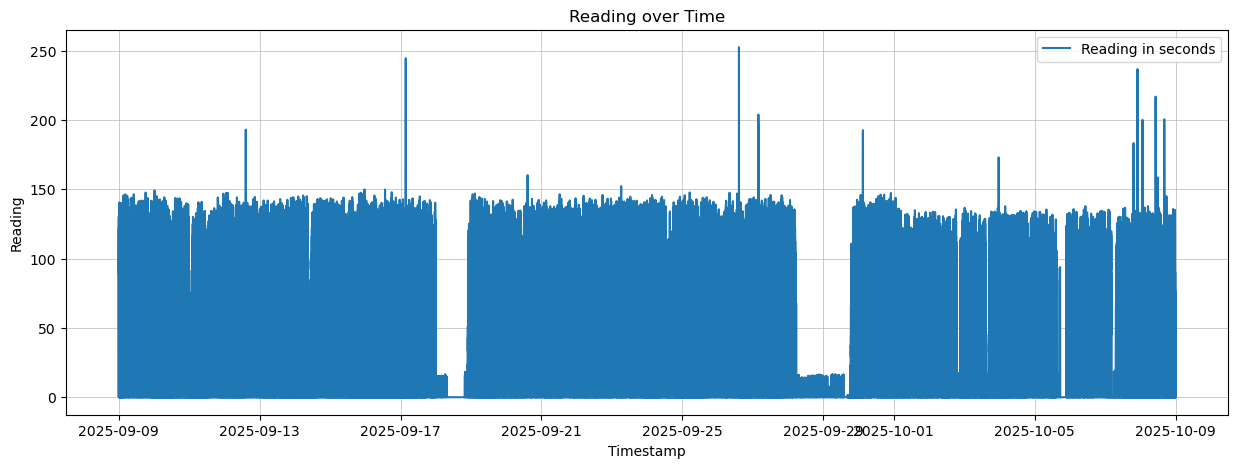

In [5]:
# Plot
plt.figure(figsize=(15,5))
plt.plot(df_5s['timestamp'], df_5s['Reading'], label="Reading in seconds")

plt.xlabel("Timestamp")
plt.ylabel("Reading")
plt.title("Reading over Time")

plt.grid(
    True,
    alpha=0.9,        # transparency (lower = lighter) (0-1)
    linestyle='-',   # dashed grid
    linewidth=0.5     # line thickness
)
plt.legend()

plt.show()

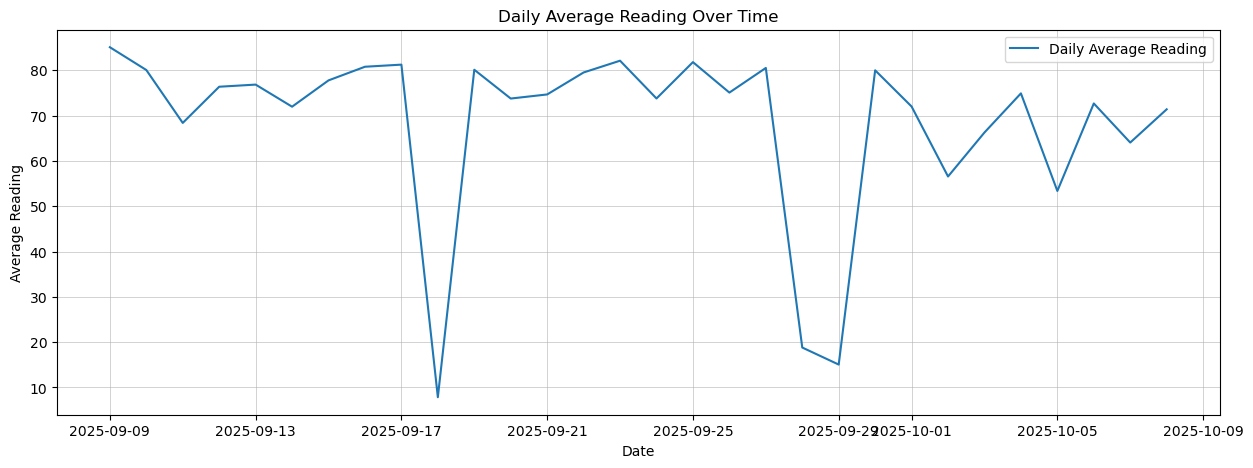

In [6]:
df_5s['date'] = df_5s['timestamp'].apply(lambda x: x.date())
daily_df = df_5s.groupby('date')['Reading'].mean()

plt.figure(figsize=(15,5))
plt.plot(daily_df.index, daily_df.values, label='Daily Average Reading')

plt.xlabel("Date")
plt.ylabel("Average Reading")
plt.title("Daily Average Reading Over Time")

plt.grid(
    True,
    alpha=0.8,        # transparency (lower = lighter) (0-1)
    linestyle='-',   # dashed grid
    linewidth=0.5     # line thickness
)
plt.legend()

plt.show()

# Check stationarity

In [ ]:
daily_readings = int(24*60*60/5)
hourly_readings = int(60*60/5)
two_hourly_readings = int(2*60*60/5)
few_hourly_readings = int(4*60*60/5)
daily_readings, hourly_readings, two_hourly_readings, few_hourly_readings

(17280, 720, 1440, 2880)

In [ ]:
window_len = few_hourly_readings
rolling_mean = df_5s['Reading'].rolling(window=window_len).mean()
rolling_std = df_5s['Reading'].rolling(window=window_len).std()

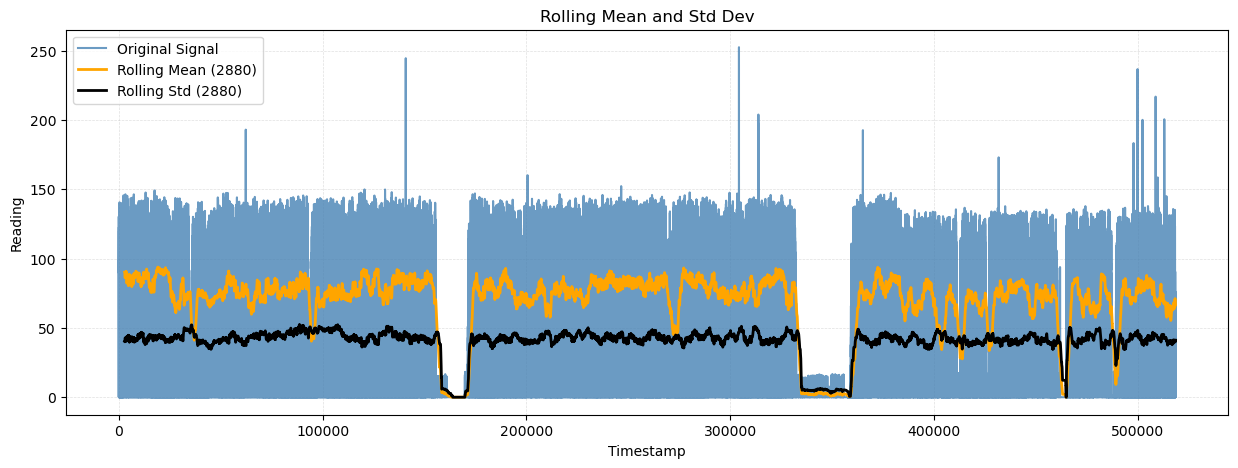

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(df_5s.index, df_5s['Reading'], label='Original Signal', alpha=0.8, color='steelblue')
plt.plot(df_5s.index, rolling_mean, label=f'Rolling Mean ({window_len})', linewidth=2, color='orange')
plt.plot(df_5s.index, rolling_std, label=f'Rolling Std ({window_len})', linewidth=2, color='black')

plt.xlabel("Timestamp")
plt.ylabel("Reading")
plt.title("Rolling Mean and Std Dev")

plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
plt.legend()

plt.show()

In [ ]:
# ADF Test
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_5s['Reading'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

for key, value in result[4].items():
    print(f'Critical Value ({key}): {value}')

ADF Statistic: -36.952180683746214
p-value: 0.0
Critical Value (1%): -3.430362616911063
Critical Value (5%): -2.8615455765266176
Critical Value (10%): -2.5667729681813385


# Seasonality Decomposition

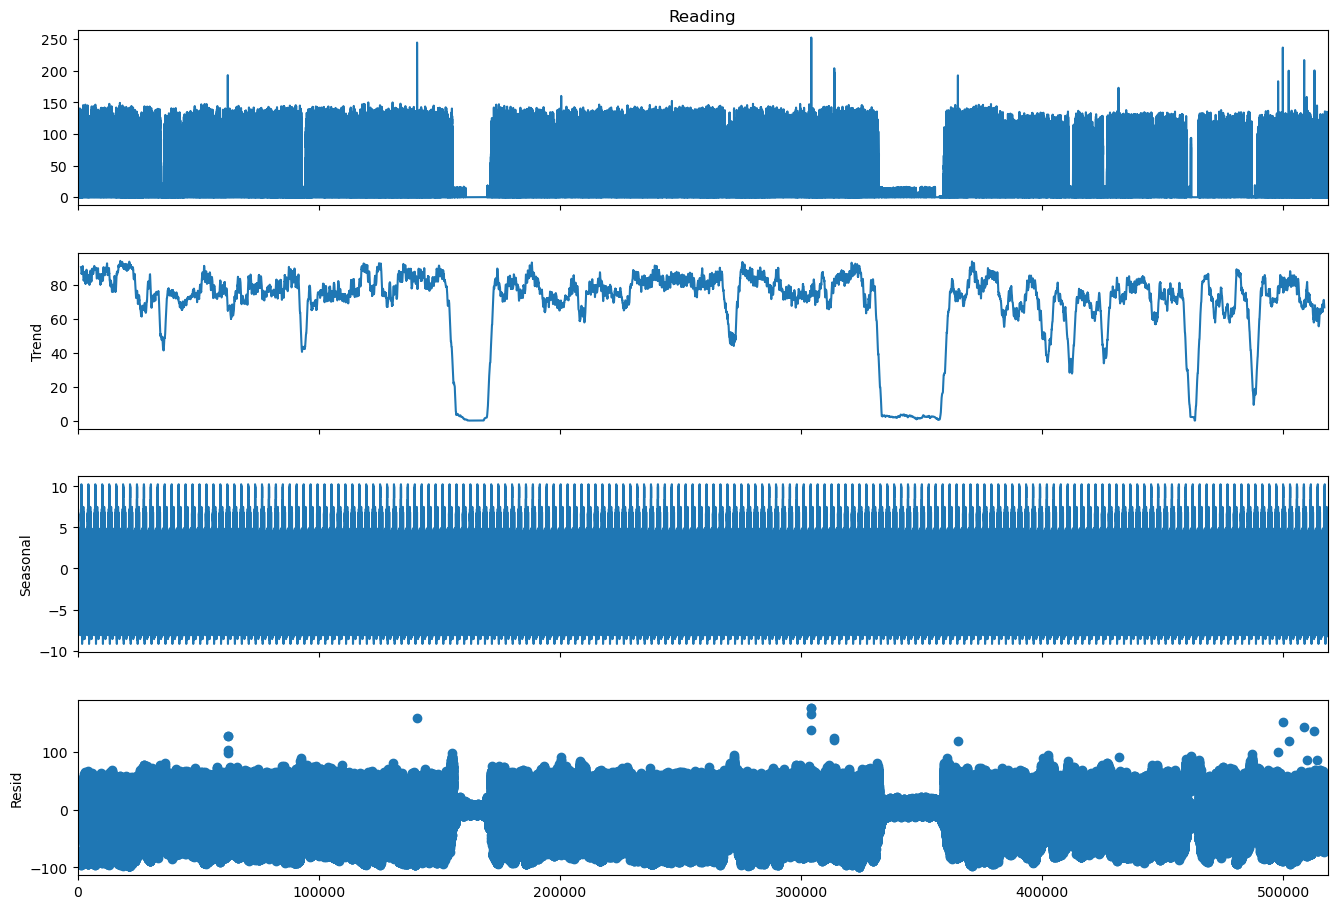

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    df_5s['Reading'],
    model='additive',
    period=2880
)

fig = decomposition.plot()
fig.set_size_inches(15, 10)

# Outlier detection

In [14]:
# Global statistics
mean_val = df_5s['Reading'].mean()
std_val = df_5s['Reading'].std()

upper_limit = mean_val + 3 * std_val
lower_limit = mean_val - 3 * std_val

outliers_global = df_5s[
    (df_5s['Reading'] > upper_limit) |
    (df_5s['Reading'] < lower_limit)
]

print("Number of outliers:", len(outliers_global))

outliers_global.head()

Number of outliers: 7


,timestamp,Reading,date
140786,2025-09-17 03:32:10,244.61554,2025-09-17
304233,2025-09-26 14:32:45,216.19038,2025-09-26
304234,2025-09-26 14:32:50,241.33929,2025-09-26
304235,2025-09-26 14:32:55,251.57131,2025-09-26
304236,2025-09-26 14:33:00,252.55373,2025-09-26


NameError: name 'rolling_mean' is not defined

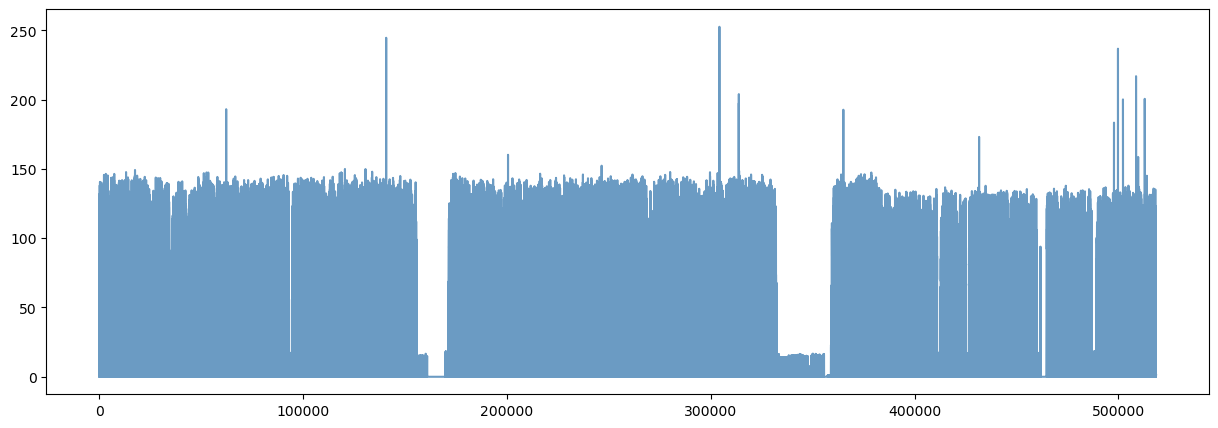

In [15]:
plt.figure(figsize=(15,5))

plt.plot(df_5s.index, df_5s['Reading'], label='Original Signal', alpha=0.8, color='steelblue')
plt.plot(df_5s.index, rolling_mean, label=f'Rolling Mean ({window_len})', linewidth=2, color='orange')
plt.plot(df_5s.index, rolling_std, label=f'Rolling Std ({window_len})', linewidth=2, color='black')

plt.scatter(outliers_global.index, outliers_global['Reading'], color='red', label='Global Outliers', s=15)
plt.axhline(mean_val, color='green', linestyle='--', linewidth=2, label='Global Mean')
plt.axhline(std_val, color='black', linestyle='--', linewidth=2, label='Global Std')
plt.axhline(upper_limit, color='gold', linestyle='--', linewidth=2, label='+3 Std')
plt.axhline(lower_limit, color='gold', linestyle='--', linewidth=2, label='-3 Std')

plt.xlabel("Timestamp")
plt.ylabel("Reading")
plt.title("Global Outlier Detection")

plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
plt.legend()

plt.show()

In [ ]:
# Rolling statistics
rolling_mean = df_5s['Reading'].rolling(window=window_len).mean()
rolling_std = df_5s['Reading'].rolling(window=window_len).std()

# Dynamic thresholds
# upper_bound = rolling_mean + 3 * rolling_std
# lower_bound = rolling_mean - 3 * rolling_std
upper_bound = rolling_mean + 3 * std_val
lower_bound = rolling_mean - 3 * std_val

# Detect rolling outliers
outliers = df_5s[
    (df_5s['Reading'] > upper_bound) |
    (df_5s['Reading'] < lower_bound)
]

print("Number of outliers:", len(outliers))

outliers.head()

Number of outliers: 7


,timestamp,Reading,date
140786,2025-09-17 03:32:10,244.61554,2025-09-17
304233,2025-09-26 14:32:45,216.19038,2025-09-26
304234,2025-09-26 14:32:50,241.33929,2025-09-26
304235,2025-09-26 14:32:55,251.57131,2025-09-26
304236,2025-09-26 14:33:00,252.55373,2025-09-26


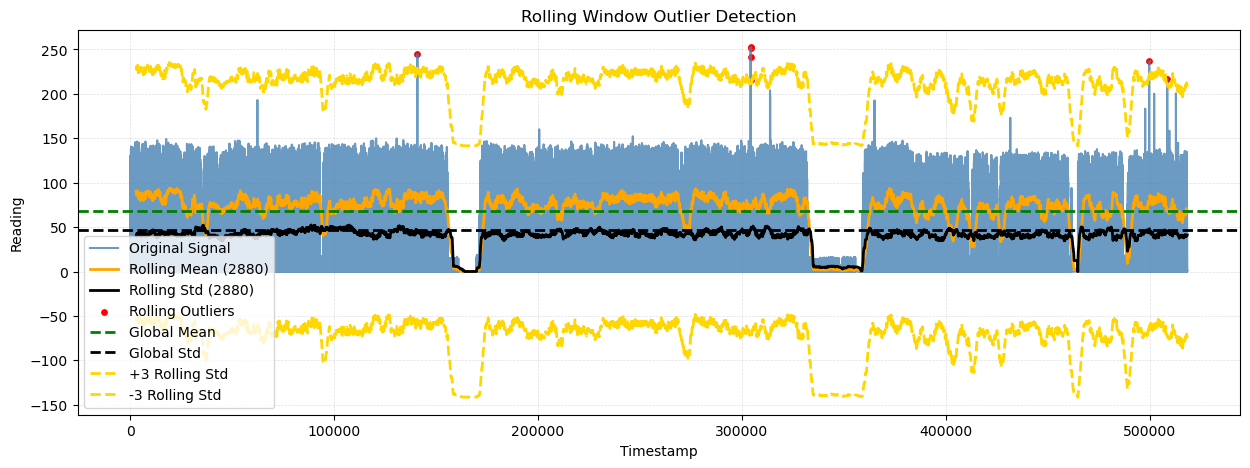

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(df_5s.index, df_5s['Reading'], label='Original Signal', alpha=0.8, color='steelblue')
plt.plot(df_5s.index, rolling_mean, label=f'Rolling Mean ({window_len})', linewidth=2, color='orange')
plt.plot(df_5s.index, rolling_std, label=f'Rolling Std ({window_len})', linewidth=2, color='black')

plt.scatter(outliers.index, outliers['Reading'], color='red', label='Rolling Outliers', s=15)
plt.axhline(mean_val, color='green', linestyle='--', linewidth=2, label='Global Mean')
plt.axhline(std_val, color='black', linestyle='--', linewidth=2, label='Global Std')
plt.plot(upper_bound.index, upper_bound, color='gold', linestyle='--', linewidth=2, label='+3 Rolling Std')
plt.plot(lower_bound.index, lower_bound, color='gold', linestyle='--', linewidth=2, label='-3 Rolling Std')

plt.xlabel("Timestamp")
plt.ylabel("Reading")
plt.title("Rolling Window Outlier Detection")

plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
plt.legend()

plt.show()

# ACF PACF Plots

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
lag_len = int(60*60/5)
# lag_len = int(60/5)

<Figure size 1500x500 with 0 Axes>

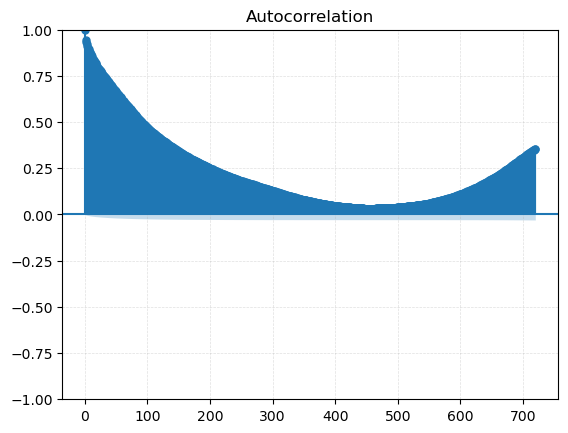

In [8]:
plt.figure(figsize=(15,5))
plot_acf(df_5s['Reading'].dropna(), lags=lag_len)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)

plt.show()

<Figure size 1500x500 with 0 Axes>

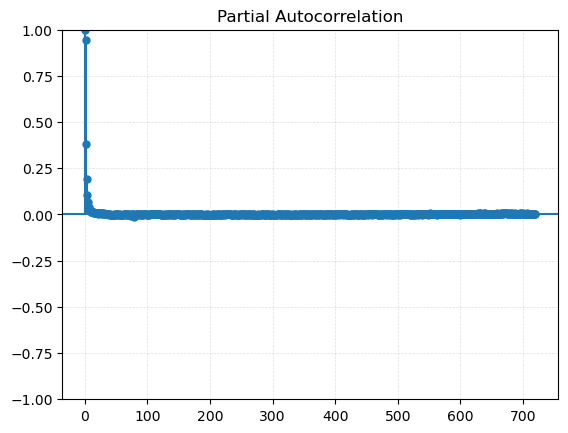

In [9]:
plt.figure(figsize=(15,5))
plot_pacf(df_5s['Reading'].dropna(), lags=lag_len, method='ywm')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)

plt.show()

In [10]:
lag_len = 200 #int(60/5)

<Figure size 1500x500 with 0 Axes>

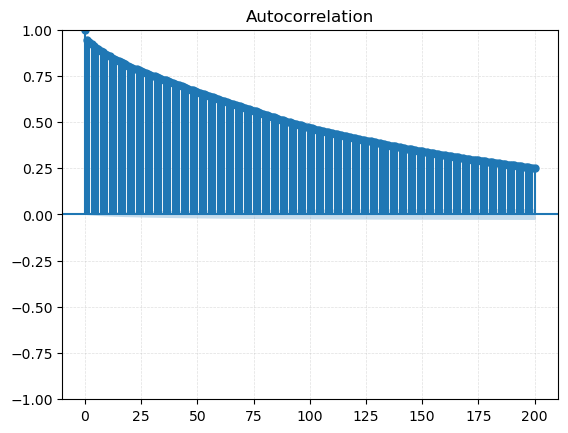

In [11]:
plt.figure(figsize=(15,5))
plot_acf(df_5s['Reading'].dropna(), lags=lag_len)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)

plt.show()

<Figure size 1500x500 with 0 Axes>

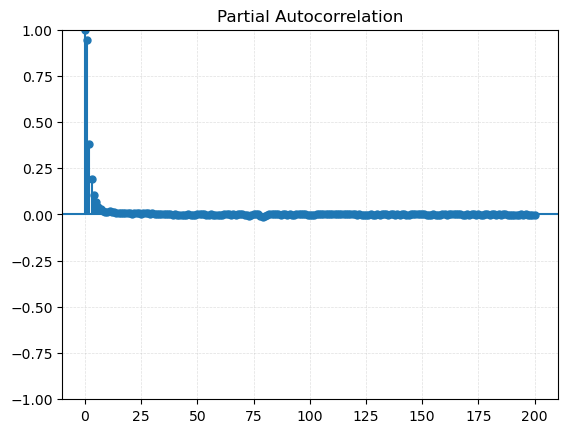

In [12]:
plt.figure(figsize=(15,5))
plot_pacf(df_5s['Reading'].dropna(), lags=lag_len, method='ywm')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)

plt.show()

# Model training

### 1. Test train split

In [7]:
test_days_split = 7
# split_index = int(len(df_5s) * 0.8)
split_index = int(len(df_5s) - (test_days_split*24*60*60/5))

train = df_5s.iloc[:split_index]
test = df_5s.iloc[split_index:]

print(train.shape)
print(test.shape)

(397440, 3)
(120960, 3)


In [8]:
train['timestamp'].describe()

count                        397440
mean     2025-09-20 11:59:57.500000
min             2025-09-09 00:00:00
25%      2025-09-14 17:59:58.750000
50%      2025-09-20 11:59:57.500000
75%      2025-09-26 05:59:56.250000
max             2025-10-01 23:59:55
Name: timestamp, dtype: object

In [9]:
test['timestamp'].describe()

count                        120960
mean     2025-10-05 11:59:57.500000
min             2025-10-02 00:00:00
25%      2025-10-03 17:59:58.750000
50%      2025-10-05 11:59:57.500000
75%      2025-10-07 05:59:56.250000
max             2025-10-08 23:59:55
Name: timestamp, dtype: object

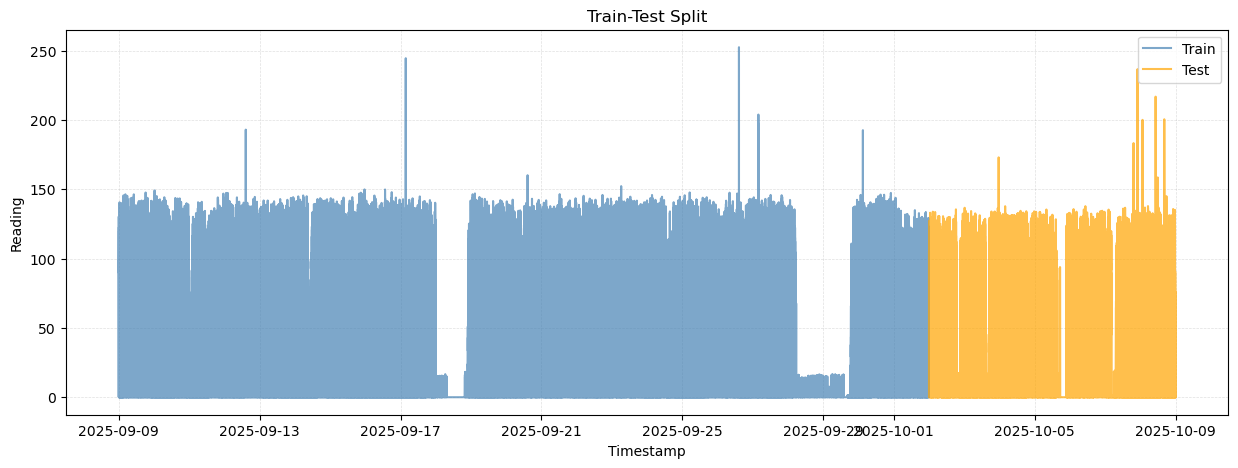

In [36]:
plt.figure(figsize=(15,5))

plt.plot(train['timestamp'], train['Reading'], label='Train', alpha=0.7, color='steelblue')
plt.plot(test['timestamp'], test['Reading'], label='Test', alpha=0.7, color='orange')

plt.xlabel("Timestamp")
plt.ylabel("Reading")
plt.title("Train-Test Split")

plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
plt.legend()

plt.show()

### 2. Baseline model

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_forecast(y_true, y_pred, model_name="Model"):
    
    # Convert to numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Remove NaNs
    mask = (~np.isnan(y_true)) & (~np.isnan(y_pred))
    
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    
    mae = float(mean_absolute_error(y_true, y_pred))    
    mse = float(mean_squared_error(y_true, y_pred))
    rmse = float(np.sqrt(mse))
    r2 = float(r2_score(y_true, y_pred))
    
    # Safe MAPE calculation
    non_zero_mask = y_true != 0
    if non_zero_mask.sum() > 0:
        mape = float(
            np.mean(
                np.abs(
                    (y_true[non_zero_mask] - y_pred[non_zero_mask]) /
                    y_true[non_zero_mask]
                )
            ) * 100
        )
    else:
        mape = np.nan
    
    # Print results
    print(f"\n----- {model_name} Evaluation -----")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAPE : {mape:.2f}%")
    print(f"R2   : {r2:.4f}")
    
    # Return dictionary
    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2
    }

In [ ]:
train_eval_report = []
eval_report = []
all_predictions = test.drop(columns='date').copy()

In [ ]:
# =========================
# Moving Average Baseline
# =========================

window_hrs = 1
window = int(window_hrs * 60 * 60 / 5)
print(f"Window length: {window}")

moving_avg_train = train['Reading'].rolling(window=window).mean().shift(1)

actual = train['Reading'][window:]
pred_on_train = moving_avg_train[window:]
    
train_eval_ma = evaluate_forecast(actual, pred_on_train, "Baseline Moving Average on train")
train_eval_report.append(train_eval_ma)

Window length: 720

----- Baseline Moving Average on train Evaluation -----
MAE  : 34.4171
MSE  : 1924.9756
RMSE : 43.8745
MAPE : 1056.46%
R2   : 0.1586


In [ ]:
# =========================
# Recursive Forecasting
# =========================

history = list(train['Reading'].iloc[-window:])
predictions = []

for _ in range(len(test)):
    pred = np.mean(history[-window:])    
    predictions.append(pred)
    history.append(pred)

predictions = pd.Series(predictions,index=test.index)
print("Test length:", test.shape[0])
print("Predictions length:", predictions.shape[0])
print()

eval_report_ma = evaluate_forecast(test['Reading'], predictions, "Baseline Moving Average")
all_predictions['Baseline MA'] = predictions
eval_report.append(eval_report_ma)

Test length: 120960
Predictions length: 120960


----- Baseline Moving Average Evaluation -----
MAE  : 37.7162
MSE  : 2209.7820
RMSE : 47.0083
MAPE : 1142.76%
R2   : -0.1004


In [ ]:
pd.DataFrame(train_eval_report + eval_report)

,Model,MAE,MSE,RMSE,MAPE,R2
0,Baseline Moving Average on train,34.417053,1924.975583,43.874544,1056.459020,0.158586
1,Baseline Moving Average,37.716172,2209.781983,47.008318,1142.764854,-0.100427


### 3. Model : ARIMA (3, 0, 0)

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train['Reading'], order=(3,0,0))
arima_model_fit = arima_model.fit()

train_pred = arima_model_fit.predict(start=train.index[0], end=train.index[-1])
eval_report_arima_train = evaluate_forecast(train['Reading'], train_pred, "ARIMA(3,0,0) Train")

train_eval_report.append(eval_report_arima_train)


----- ARIMA(3,0,0) Train Evaluation -----
MAE  : 6.8334
MSE  : 197.1869
RMSE : 14.0423
MAPE : 46.66%
R2   : 0.9138


In [ ]:
print(arima_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Reading   No. Observations:               397440
Model:                 ARIMA(3, 0, 0)   Log Likelihood            -1614009.024
Date:                Tue, 26 May 2026   AIC                        3228028.048
Time:                        12:09:28   BIC                        3228082.512
Sample:                             0   HQIC                       3228043.614
                             - 397440                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         69.2709      1.076     64.390      0.000      67.162      71.379
ar.L1          0.5112      0.001    726.964      0.000       0.510       0.513
ar.L2          0.2666      0.001    303.247      0.0

In [ ]:
forecast = arima_model_fit.forecast(steps=len(test))

eval_report_arima = evaluate_forecast(test['Reading'], forecast, "ARIMA(3,0,0)")
all_predictions['ARIMA 3_0_0'] = forecast
eval_report.append(eval_report_arima)


----- ARIMA(3,0,0) Evaluation -----
MAE  : 39.2587
MSE  : 2020.9327
RMSE : 44.9548
MAPE : 995.95%
R2   : -0.0064


In [ ]:
pd.DataFrame(train_eval_report + eval_report)

,Model,MAE,MSE,RMSE,MAPE,R2
0,Baseline Moving Average on train,34.417053,1924.975583,43.874544,1056.459020,0.158586
1,"ARIMA(3,0,0) Train",6.833428,197.186865,14.042324,46.657733,0.913791
2,Baseline Moving Average,37.716172,2209.781983,47.008318,1142.764854,-0.100427
3,"ARIMA(3,0,0)",39.258676,2020.932708,44.954785,995.946492,-0.006384


### 4. Model : ARIMA (5, 0 , 0)

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Model Train
arima_model = ARIMA(train['Reading'], order=(5,0,0))
arima_model_fit = arima_model.fit()

train_pred = arima_model_fit.predict(start=train.index[0], end=train.index[-1])
eval_report_arima_train = evaluate_forecast(train['Reading'], train_pred, "ARIMA(5,0,0) Train")

train_eval_report.append(eval_report_arima_train)

# Forecast
forecast = arima_model_fit.forecast(steps=len(test))

eval_report_arima = evaluate_forecast(test['Reading'], forecast, "ARIMA(5,0,0)")
all_predictions['ARIMA 5_0_0'] = forecast
eval_report.append(eval_report_arima)


----- ARIMA(5,0,0) Train Evaluation -----
MAE  : 6.7477
MSE  : 193.9776
RMSE : 13.9276
MAPE : 46.03%
R2   : 0.9152

----- ARIMA(5,0,0) Evaluation -----
MAE  : 39.2529
MSE  : 2020.7516
RMSE : 44.9528
MAPE : 995.95%
R2   : -0.0063


In [ ]:
print(arima_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Reading   No. Observations:               397440
Model:                 ARIMA(5, 0, 0)   Log Likelihood            -1610748.193
Date:                Tue, 26 May 2026   AIC                        3221510.386
Time:                        12:10:06   BIC                        3221586.635
Sample:                             0   HQIC                       3221532.179
                             - 397440                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         69.2709      1.335     51.886      0.000      66.654      71.888
ar.L1          0.4828      0.001    685.871      0.000       0.481       0.484
ar.L2          0.2282      0.001    230.902      0.0

In [ ]:
pd.DataFrame(train_eval_report + eval_report)

,Model,MAE,MSE,RMSE,MAPE,R2
0,Baseline Moving Average on train,34.417053,1924.975583,43.874544,1056.459020,0.158586
1,"ARIMA(3,0,0) Train",6.833428,197.186865,14.042324,46.657733,0.913791
2,"ARIMA(5,0,0) Train",6.747698,193.977601,13.927584,46.030109,0.915194
3,Baseline Moving Average,37.716172,2209.781983,47.008318,1142.764854,-0.100427
4,"ARIMA(3,0,0)",39.258676,2020.932708,44.954785,995.946492,-0.006384
5,"ARIMA(5,0,0)",39.252946,2020.751579,44.952771,995.953223,-0.006294


### 5. Model : SARIMAX (3, 0 , 0) (1, 0, 0, 12)

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Model Train
seasonal_period = int(60/5)
print(f"Seasonal Period: {seasonal_period}")
sarima_model = SARIMAX(train['Reading'], order=(3,0,0), seasonal_order=(1,0,1,seasonal_period), 
                       enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima_model.fit()

train_pred = sarima_fit.predict(start=train.index[0], end=train.index[-1])
eval_report_sarima_train = evaluate_forecast(train['Reading'], train_pred, f"SARIMA(3,0,0)(1,0,1,{seasonal_period}) Train")

train_eval_report.append(eval_report_sarima_train)

# Forecast
forecast = sarima_fit.forecast(steps=len(test))

eval_report_sarima = evaluate_forecast(test['Reading'], forecast, f"SARIMA(3,0,0)(1,0,1,{seasonal_period})")
all_predictions[f'SARIMA 3_0_0_{seasonal_period}'] = forecast
eval_report.append(eval_report_sarima)

Seasonal Period: 12

----- SARIMA(3,0,0)(1,0,1,12) Train Evaluation -----
MAE  : 6.4287
MSE  : 198.3148
RMSE : 14.0824
MAPE : 22.96%
R2   : 0.9133

----- SARIMA(3,0,0)(1,0,1,12) Evaluation -----
MAE  : 65.4458
MSE  : 6289.8417
RMSE : 79.3085
MAPE : 100.24%
R2   : -2.1322


In [ ]:
pd.DataFrame(train_eval_report + eval_report)

,Model,MAE,MSE,RMSE,MAPE,R2
0,Baseline Moving Average on train,34.417053,1924.975583,43.874544,1056.459020,0.158586
1,"ARIMA(3,0,0) Train",6.833428,197.186865,14.042324,46.657733,0.913791
2,"ARIMA(5,0,0) Train",6.747698,193.977601,13.927584,46.030109,0.915194
3,"SARIMA(3,0,0)(1,0,1,12) Train",6.428741,198.314761,14.082427,22.961720,0.913298
4,Baseline Moving Average,37.716172,2209.781983,47.008318,1142.764854,-0.100427
5,"ARIMA(3,0,0)",39.258676,2020.932708,44.954785,995.946492,-0.006384
6,"ARIMA(5,0,0)",39.252946,2020.751579,44.952771,995.953223,-0.006294
7,"SARIMA(3,0,0)(1,0,1,12)",65.445777,6289.841687,79.308522,100.241961,-2.132216


In [ ]:
print(sarima_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                              Reading   No. Observations:               397440
Model:             SARIMAX(3, 0, 0)x(1, 0, [1], 12)   Log Likelihood            -1615038.639
Date:                              Tue, 26 May 2026   AIC                        3230089.277
Time:                                      12:14:41   BIC                        3230154.634
Sample:                                           0   HQIC                       3230107.957
                                           - 397440                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5176      0.001    831.436      0.000       0.516       0.519
ar.L2          0.27

# Forecast for future using entire history

In [40]:
from statsmodels.tsa.arima.model import ARIMA

FORECAST_HORIZON = int(3 * 60 * 60 / 5)       # 2160  (3-hour horizon)

# Model Train
arima_model = ARIMA(df_5s['Reading'], order=(3,0,0))
arima_model_fit = arima_model.fit()

train_pred = arima_model_fit.predict(start=df_5s.index[0], end=df_5s.index[-1])
eval_report_arima_train = evaluate_forecast(df_5s['Reading'], train_pred, "ARIMA(3,0,0) Entire")

train_eval_report.append(eval_report_arima_train)

# Future Forecast
final_forecast = arima_model_fit.forecast(steps=FORECAST_HORIZON)
last_timestamp = df_5s['timestamp'].iloc[-1]
future_timestamps = pd.date_range(start=last_timestamp + pd.Timedelta(seconds=5), 
                                  periods=FORECAST_HORIZON, freq='5s')
forecast_df = pd.DataFrame({'timestamp': future_timestamps, 'forecast': final_forecast.values})
forecast_df.to_csv("forecast_from_arima.csv", index=False)
forecast_df


----- ARIMA(3,0,0) Entire Evaluation -----
MAE  : 6.9400
MSE  : 203.0726
RMSE : 14.2504
MAPE : 47.27%
R2   : 0.9087


,timestamp,forecast
0,2025-10-09 00:00:00,3.136620
1,2025-10-09 00:00:05,4.112107
2,2025-10-09 00:00:10,5.122376
3,2025-10-09 00:00:15,6.269505
4,2025-10-09 00:00:20,7.314010
...,...,...
2155,2025-10-09 02:59:35,68.411918
2156,2025-10-09 02:59:40,68.411918
2157,2025-10-09 02:59:45,68.411918
2158,2025-10-09 02:59:50,68.411918


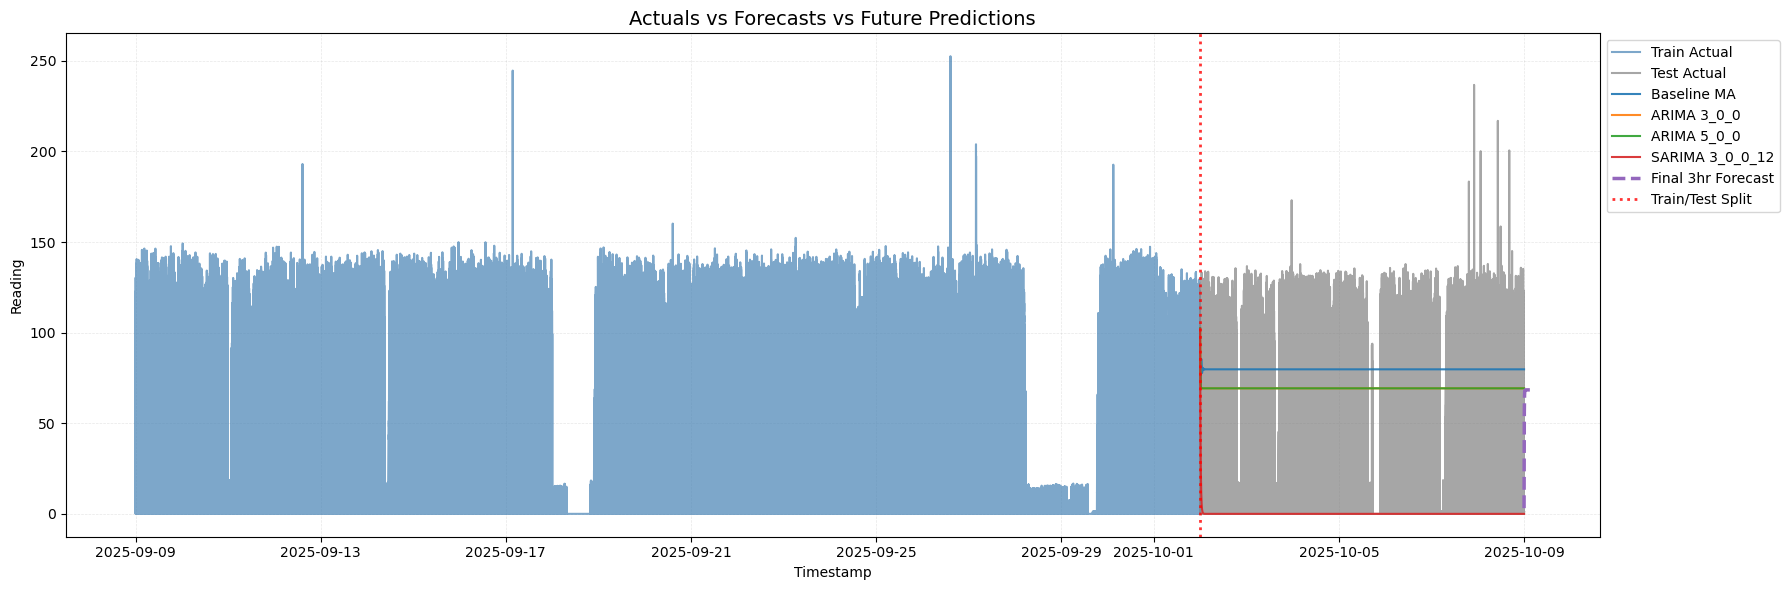

In [41]:
plt.figure(figsize=(18,6))

plt.plot(train['timestamp'], train['Reading'], label='Train Actual', alpha=0.7, color='steelblue')
plt.plot(test['timestamp'], test['Reading'], label='Test Actual', alpha=0.7, color='grey')

prediction_cols = ['Baseline MA', 'ARIMA 3_0_0', 'ARIMA 5_0_0', 'SARIMA 3_0_0_12']
for col in prediction_cols:
    plt.plot(all_predictions['timestamp'], all_predictions[col], label=col, linewidth=1.5, alpha=0.9)

plt.plot(forecast_df['timestamp'], forecast_df['forecast'], label='Final 3hr Forecast', linewidth=2.5, linestyle='--')

plt.axvline(x=test['timestamp'].iloc[0], color='red', linestyle=':', linewidth=2, alpha=0.8, label='Train/Test Split')

plt.xlabel("Timestamp")
plt.ylabel("Reading")
plt.title("Actuals vs Forecasts vs Future Predictions", fontsize=14)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.tight_layout()

plt.show()

### 6. Model (Very compute heavy) : SARIMAX (3, 0 , 0) (1, 0, 0, 720)

In [ ]:
# from statsmodels.tsa.statespace.sarimax import SARIMAX

# # Model Train
# seasonal_period = int(60*60/5)
# print(f"Seasonal Period: {seasonal_period}")
# sarima_model = SARIMAX(train['Reading'], order=(3,0,0), seasonal_order=(1,0,1,seasonal_period), 
#                        enforce_stationarity=False, enforce_invertibility=False)
# sarima_fit = sarima_model.fit()

# train_pred = sarima_fit.predict(start=train.index[0], end=train.index[-1])
# eval_report_sarima_train = evaluate_forecast(train['Reading'], train_pred, f"SARIMA(3,0,0)(1,0,1,{seasonal_period}) Train")

# train_eval_report.append(eval_report_sarima_train)

# # Forecast
# forecast = sarima_fit.forecast(steps=len(test))

# eval_report_sarima = evaluate_forecast(test['Reading'], forecast, f"SARIMA(3,0,0)(1,0,1,{seasonal_period})")
# all_predictions[f'SARIMA 3_0_0_{seasonal_period}'] = forecast
# eval_report.append(eval_report_sarima)

Seasonal Period: 720


In [ ]:
# pd.DataFrame(train_eval_report + eval_report)

In [ ]:
# print(sarima_fit.summary())